### 데이터의 불균형 문제 
- 정상을 정확하게 분류하는 것과 이상을 정확하게 분류하는 것중 이상을 정확하게 분류하는 것이 중요
- 일반적으로는 정상의 데이터가 이상의 데이터보다 많다. 
- 데이터의 불균형이 발생할 수 있다. 
- target 데이터에서 0(정상), 1(이상)중에 0을 판단을 더 많이 하게 되는 경우가 발생(예측력이 떨어진다.)
- 소수의 데이터의 중요도가 낮게 판단이 되서 실제 모델에서는 해당하는 예측이 적게 발생 
- 다수의 데이터와 소수의 데이터를 특정 비율로 조절해주는 샘플링 기법이 존재 ( 언더 샘플링, 오버 샘플링 )
- 샘플링을 사용하기 위한 라이브러리 설치 (imbalanced-learn)

In [522]:
# !pip install imbalanced-learn

- 언더 샘플링 
    - 다수의 라벨을 가진 데이터를 샘플링하여 소수의 데이터의 수 수준으로 감소 시키는 방법
    - 데이터 불균형 문제는 해결이 되지만 전체 데이터의 개수가 감소하여 학습의 성능이 떨어질수 있다. 

In [523]:
import pandas as pd 
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

In [524]:
# 머신러닝에서는 독립 변수와 종속 변수를 이용 
# make_classification() 함수는 데이터가 불균형한 랜덤 데이터를 생성 결과가 독립변수, 종속변수 따로 데이터를 제공

# 불균형 데이터셋 생성 
x, y = make_classification(
    n_samples= 1000, 
    n_features= 5, 
    weights = [0.9], 
    flip_y=0
)

In [525]:
x

array([[-1.24688679,  1.41860526,  0.30750871, -0.03521068,  0.51539969],
       [-0.09788503, -1.08954433,  0.20840271, -0.83486232, -0.33511729],
       [ 2.53259152, -2.37952696, -0.70159195, -0.66359528, -0.8898947 ],
       ...,
       [-0.95511223,  0.39899212,  0.34106176,  1.20796536,  0.17973424],
       [-1.07136203, -0.96692544,  0.59960494, -0.52481928, -0.24076067],
       [ 1.15599667, -0.7752259 , -0.36794415,  0.80156969, -0.30895702]],
      shape=(1000, 5))

In [526]:
y

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,

In [527]:
Counter(y)

Counter({np.int64(0): 901, np.int64(1): 99})

In [528]:
# 데이터프레임으로 생성 
df = pd.DataFrame(x)
# target 데이터 y도 데이터프레임에 포함 
df['target'] = y

df.head()

,0,1,2,3,4,target
0,-1.246887,1.418605,0.307509,-0.035211,0.515400,0
1,-0.097885,-1.089544,0.208403,-0.834862,-0.335117,0
2,2.532592,-2.379527,-0.701592,-0.663595,-0.889895,1
3,-0.707372,1.192769,0.114923,2.647806,0.413730,0
4,-0.841627,-1.031561,0.512761,2.330904,-0.274193,0


In [529]:
# RandomUnderSampler 라는 class를 생성
undersampler = RandomUnderSampler()

In [530]:
under_x , under_y = undersampler.fit_resample(x, y)

In [531]:
Counter(under_y)

Counter({np.int64(0): 99, np.int64(1): 99})

In [532]:
under_df = pd.DataFrame(under_x)
under_df['target'] = under_y

under_df['target'].value_counts()

target
0    99
1    99
Name: count, dtype: int64

In [533]:
# undersampler에서 데이터의 비율을 변경 
# class 생성할때 비율을 지정
# sampling_strategy 매개변수 -> 소수의 데이터의 비율을 의미 
undersampler2 = RandomUnderSampler(sampling_strategy=0.5)

In [534]:
x_under2, y_under2 = undersampler2.fit_resample(x, y)

In [535]:
Counter(y_under2)

Counter({np.int64(0): 198, np.int64(1): 99})

- 오버 샘플링 
    - 소수의 데이터를 다수의 데이터의 개수만큼 증가시켜 학습에 사용하기 위한 방법 
    - 데이터의 손실이 없기때문에 일반적으로는 언더 샘플링보다는 자주 사용

- 랜덤오버샘플링
    - 소수의 데이터를 단순 복제하여 다수의 데이터와의 비율을 맞춰주는 과정 
    - 데이터가 단순하게 복제가 되기 때문에 데이터의 분포가 변하지 않는다. 
    - 단순하게 증가시키기 때문에 추가적인 가중치가 발생 
    - 오버피팅의 위험성이 존재하지만 데이터 불균형 문제를 해결하는것이 더 중요

In [536]:
from imblearn.over_sampling import RandomOverSampler

In [537]:
oversampler = RandomOverSampler()

In [538]:
over_x, over_y = oversampler.fit_resample(x, y)

In [539]:
Counter(over_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [540]:
# 소수의 데이터 비율을 다수의 반정도로 샘플링
oversampler2 = RandomOverSampler(sampling_strategy=0.5)

In [541]:
over_x2, over_y2 = oversampler2.fit_resample(x, y)

In [542]:
Counter(over_y2)

Counter({np.int64(0): 901, np.int64(1): 450})

- SMOTE
    - 소수의 데이터의 관측값에 대한 K개의 최근접 양수를 이웃으로 찾고, 관측 값과 이웃으로 선택된 값 사이에 임의의 새로운 데이터를 생성하는 방법

In [543]:
from imblearn.over_sampling import SMOTE

In [544]:
smote = SMOTE()

In [545]:
sm_x , sm_y = smote.fit_resample(x, y)

In [546]:
Counter(sm_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [547]:
# 실제 만들어진 샘플링 데이터의 분포를 확인 
import matplotlib.pyplot as plt
import seaborn as sns

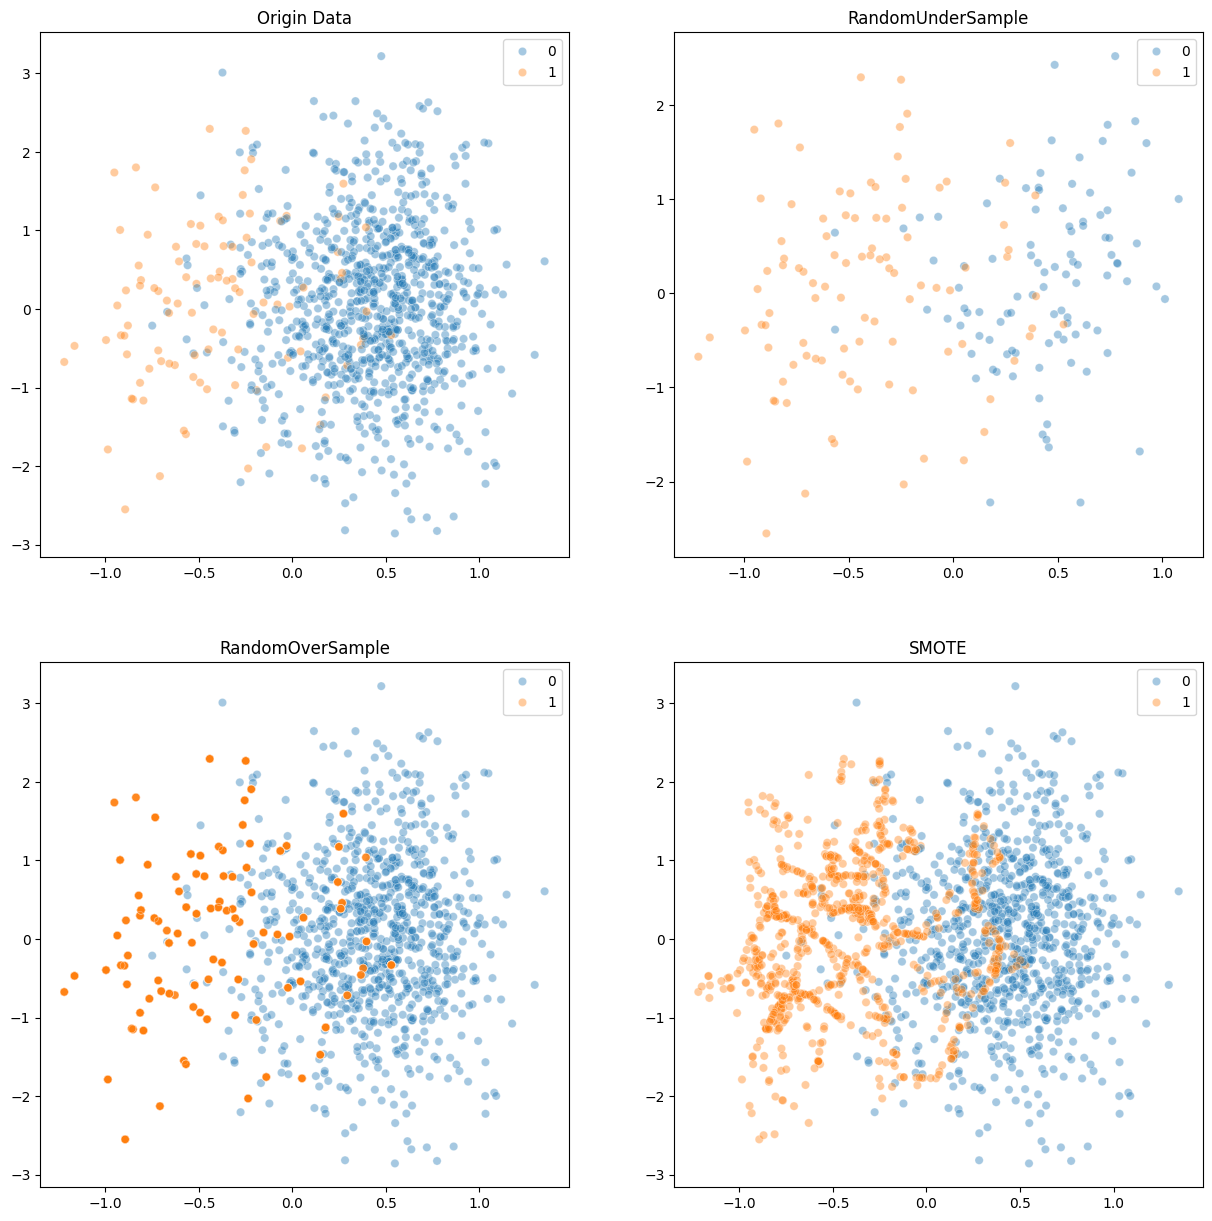

In [548]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# 4개의 산점도 그래프 생성 
sns.scatterplot(
    x = x[:, 2], y = x[:, 3], ax=axes[0][0], hue = y, alpha = 0.4
)
sns.scatterplot(
    x = under_x[:, 2], y = under_x[:, 3], ax = axes[0][1], hue=under_y, alpha=0.4 
)
sns.scatterplot(
    x = over_x[:, 2], y = over_x[:, 3], ax = axes[1][0], hue=over_y, alpha=0.4
)
sns.scatterplot(
    x = sm_x[:, 2], y = sm_x[:, 3], ax=axes[1][1], hue = sm_y, alpha = 0.4
)
axes[0][0].set_title('Origin Data')
axes[0][1].set_title('RandomUnderSample')
axes[1][0].set_title('RandomOverSample')
axes[1][1].set_title('SMOTE')

plt.show()